# Advancement accumulation over time

How fast each model piles up advancements across a 1-hour bench run.

Reads the artifacts already sitting in `state/bench/sweep-*/`, so it needs no network and
no live stack. Every trial here is the same fixed-seed world (`mineclaude-bench-1`) driven
by the `claude-code` harness — the only thing that varies is the model.

Trials whose harness got rate-limited are **held out**: a throttled run measured the rate
limiter, not the model. `usage.json` carries the flag, so the quarantine is data-driven
rather than a hardcoded run id.

## Load the runs

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

BUDGET = 3600  # seconds; only the 1-hour trials, so the curves are comparable

# Walk up to the repo root, so this runs from anywhere (repo root, bench/, bench/analysis/).
ROOT = Path.cwd()
while not (ROOT / "state" / "bench").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
BENCH = ROOT / "state" / "bench"

rows = []
for score_path in sorted(BENCH.glob("sweep-*/*/score.json")):
    meta_path = score_path.parent / "metadata.json"
    if not meta_path.exists():
        continue
    meta = json.loads(meta_path.read_text())
    if meta.get("budget_seconds") != BUDGET:
        continue
    for adv in json.loads(score_path.read_text())["breakdown"]:
        rows.append({
            "model": meta["model"],
            "run_id": meta["run_id"],
            "seed": meta["seed"],
            "offset_s": adv["offset_s"],   # seconds after the harness started
            "id": adv["id"],
            "title": adv["title"],
        })

events = pd.DataFrame(rows).sort_values(["model", "run_id", "offset_s"], ignore_index=True)
events["n"] = events.groupby("run_id").cumcount() + 1  # cumulative count within a trial

runs = (events.groupby(["model", "run_id"], as_index=False)["n"].max()
              .rename(columns={"n": "earned"}))

# The token ledger, folded out of the harness transcripts by bench/usage.py.
# cost_usd is the CLI's list-price computation — the bench authenticates with a
# subscription token, which is not billed per token, so treat it as an equivalent.
usage = []
for usage_path in BENCH.glob("sweep-*/*/usage.json"):
    u = json.loads(usage_path.read_text())
    usage.append({
        "run_id": usage_path.parent.name,
        "cost_usd": u["cost_usd"],
        "turns": u["turns"],
        "invocations": u["invocations"],
        "throttled": u["health"]["throttled"],
        **{f"tok_{k}": v for k, v in u["tokens"].items()},
    })
runs = runs.merge(pd.DataFrame(usage), on="run_id", how="left")
runs["throttled"] = runs.throttled.fillna(False)

held_out = runs[runs.throttled]
VALID = runs[~runs.throttled].reset_index(drop=True)

print(f"{len(runs)} trials · {len(events)} advancement events · seed(s): {sorted(events.seed.unique())}")
for _, r in held_out.iterrows():
    print(f"HELD OUT (throttled): {r.run_id} — {r.model}, {r.earned} advancements, ${r.cost_usd:.2f}")

(VALID.groupby("model")["earned"]
      .agg(trials="count", mean="mean", median="median", lo="min", hi="max")
      .sort_values("mean", ascending=False).round(1))

17 trials · 236 advancement events · seed(s): ['mineclaude-bench-1']
HELD OUT (throttled): 20260817-080733-t3 — claude-fable-5, 13 advancements, $8.09


,trials,mean,median,lo,hi
model,,,,,
claude-fable-5,4,15.5,15.0,15,17
claude-opus-5,6,15.3,15.0,14,17
claude-sonnet-5,6,11.5,12.0,10,12


## Palette and curves

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator

SURFACE, INK, INK_SOFT, GRIDLINE = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"

# Categorical slots 1-3, validated against this surface (worst adjacent pair:
# CVD dE 9.2, normal-vision dE 27.6). Colour is keyed to the MODEL, not to its
# rank, so adding or dropping an entry never repaints the others.
SERIES = {
    "claude-opus-5":   "#2a78d6",  # slot 1, blue
    "claude-fable-5":  "#eb6834",  # slot 2, orange
    "claude-sonnet-5": "#1baf7a",  # slot 3, aqua
}
OTHER = "#8a8a86"  # anything outside the fixed order folds here, rather than growing a 4th hue

def color_of(model):
    return SERIES.get(model, OTHER)

def short(model):
    return model.replace("claude-", "")

MODELS = [m for m in SERIES if m in set(VALID.model)]

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "text.color": INK,
    "axes.edgecolor": GRIDLINE, "axes.labelcolor": INK_SOFT,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRIDLINE, "grid.linewidth": 0.6,
})

# Advancements are discrete events, so each trial is a step function. Sample every
# trial on one common grid (10s) so averaging across trials is honest.
T = np.arange(0, BUDGET + 1, 10) / 60.0  # minutes

def curve(offsets):
    """Cumulative count at each grid time."""
    return np.searchsorted(np.sort(offsets), T * 60, side="right")

CURVES = {
    m: np.array([curve(events.loc[events.run_id == rid, "offset_s"].to_numpy())
                 for rid in VALID.loc[VALID.model == m, "run_id"]])
    for m in MODELS
}

def frame(ax, title, subtitle):
    """Recessive chrome. Call AFTER plotting — set_ylim would otherwise lock an empty axis."""
    ax.set_axisbelow(True)
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)
    ax.set_xlim(0, BUDGET / 60)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("minutes into the run")
    ax.set_ylabel("advancements earned (cumulative)")
    ax.set_title(title, loc="left", fontsize=11.5, pad=20)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=INK_SOFT, fontsize=8.5)

def label_ends(ax, ends, min_gap=0.6):
    """Direct-label each series at its right end.

    The coloured dot sits at the true value and carries the identity; the text stays in
    ink and is nudged apart just enough that two close series don't overprint.
    """
    ends = sorted(ends, key=lambda e: e[1])
    text_y = [y for _, y in ends]
    for i in range(1, len(text_y)):
        text_y[i] = max(text_y[i], text_y[i - 1] + min_gap)
    for (model, y), ty in zip(ends, text_y):
        ax.plot([T[-1]], [y], "o", color=color_of(model), ms=5, zorder=5)
        ax.annotate(f"{short(model)}  {y:.1f}", xy=(T[-1] + 0.9, ty), xycoords="data",
                    va="center", ha="left", color=INK, fontsize=9, annotation_clip=False)

## Every trial, and the mean

Thin lines are individual trials; the bold line is the mean across a model's trials.

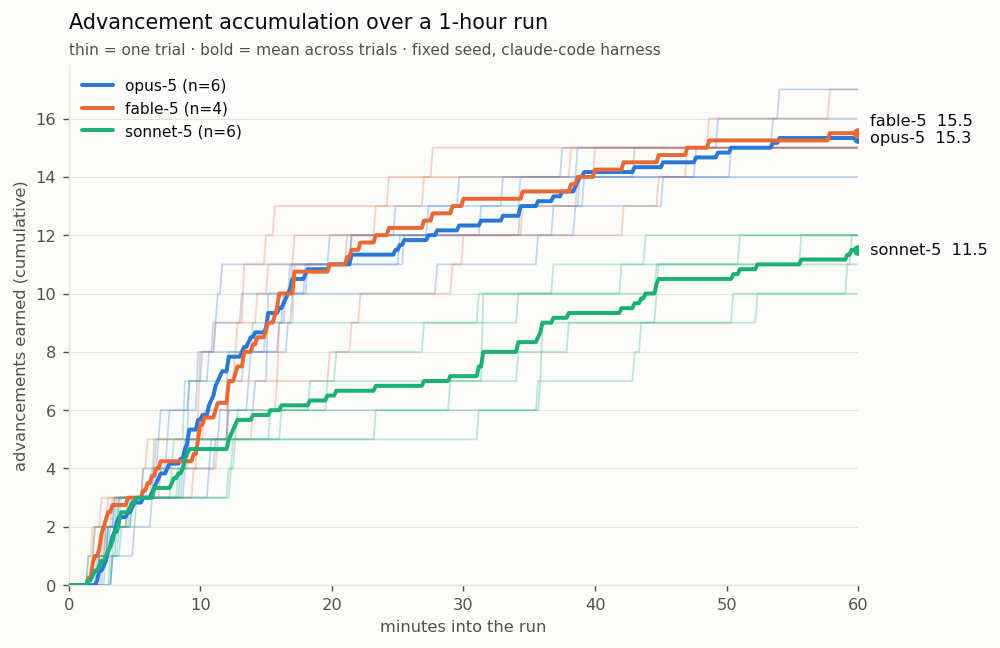

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ends = []

for model in MODELS:
    c, ys = color_of(model), CURVES[model]
    for y in ys:
        ax.plot(T, y, color=c, lw=1.0, alpha=0.28, solid_capstyle="round", zorder=2)
    mean = ys.mean(axis=0)
    ax.plot(T, mean, color=c, lw=2.2, solid_capstyle="round", zorder=4,
            label=f"{short(model)} (n={len(ys)})")
    ends.append((model, mean[-1]))

frame(ax, "Advancement accumulation over a 1-hour run",
      "thin = one trial · bold = mean across trials · fixed seed, claude-code harness")
label_ends(ax, ends)
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
fig.subplots_adjust(right=0.80)
plt.show()

## Mean, with the trial-to-trial spread

The band spans min-to-max across a model's trials — the honest read on how much of the gap
between two entries is real and how much is one lucky world.

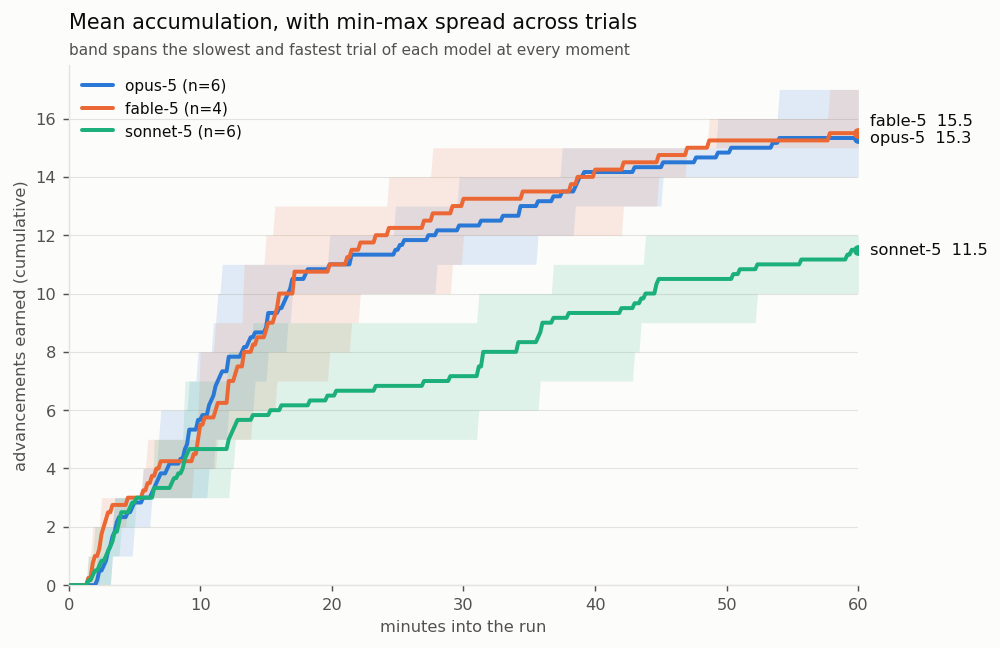

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ends = []

for model in MODELS:
    c, ys = color_of(model), CURVES[model]
    ax.fill_between(T, ys.min(axis=0), ys.max(axis=0), color=c, alpha=0.13, lw=0, zorder=2)
    mean = ys.mean(axis=0)
    ax.plot(T, mean, color=c, lw=2.2, solid_capstyle="round", zorder=4,
            label=f"{short(model)} (n={len(ys)})")
    ends.append((model, mean[-1]))

frame(ax, "Mean accumulation, with min-max spread across trials",
      "band spans the slowest and fastest trial of each model at every moment")
label_ends(ax, ends)
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
fig.subplots_adjust(right=0.80)
plt.show()

## Where the time actually goes

The curves flatten well before the buzzer. Same data, cut two ways: how much of the final
total is banked by the halfway mark, and how long each trial went silent before its budget
ran out.

In [5]:
pace = (events[events.run_id.isin(VALID.run_id)]
              .groupby(["model", "run_id"])
              .agg(earned=("n", "max"),
                   by_30min=("offset_s", lambda s: int((s <= BUDGET / 2).sum())),
                   last_earn_min=("offset_s", lambda s: s.max() / 60))
              .reset_index())
pace["banked_by_half"] = (pace.by_30min / pace.earned).round(2)
pace["silent_tail_min"] = (BUDGET / 60 - pace.last_earn_min).round(1)

display(pace.sort_values(["model", "run_id"]).round(1))

(pace.groupby("model")
     .agg(trials=("earned", "count"),
          mean_earned=("earned", "mean"),
          mean_banked_by_half=("banked_by_half", "mean"),
          mean_silent_tail_min=("silent_tail_min", "mean"))
     .sort_values("mean_earned", ascending=False).round(2))

,model,run_id,earned,by_30min,last_earn_min,banked_by_half,silent_tail_min
0,claude-fable-5,20260817-080733-t1,17,12,57.7,0.7,2.3
1,claude-fable-5,20260817-080733-t2,15,15,27.7,1.0,32.3
2,claude-fable-5,20260817-080733-t4,15,12,39.8,0.8,20.2
3,claude-fable-5,20260817-201057-t1,15,14,38.1,0.9,21.9
4,claude-opus-5,20260816-233856-t1,15,13,38.6,0.9,21.4
5,claude-opus-5,20260816-233856-t2,14,12,39.0,0.9,21.0
6,claude-opus-5,20260816-233856-t3,17,11,53.9,0.6,6.1
7,claude-opus-5,20260816-233856-t4,15,14,50.3,0.9,9.7
8,claude-opus-5,20260816-233856-t5,15,12,42.9,0.8,17.1
9,claude-opus-5,20260816-233856-t6,16,12,49.3,0.8,10.7


,trials,mean_earned,mean_banked_by_half,mean_silent_tail_min
model,,,,
claude-fable-5,4,15.50,0.86,19.17
claude-opus-5,6,15.33,0.81,14.33
claude-sonnet-5,6,11.50,0.62,8.90


## What a run costs

Token ledger per model. `cost_usd` is the CLI's list-price computation — these runs
authenticated with a subscription token, which is not billed per token, so read it as a
list-price equivalent rather than an invoice. The token counts are real either way.

In [6]:
cost = (VALID.groupby("model")
             .agg(trials=("earned", "count"),
                  adv=("earned", "mean"),
                  cost_usd=("cost_usd", "mean"),
                  turns=("turns", "mean"),
                  out=("tok_output", "mean"),
                  thinking=("tok_thinking", "mean"),
                  cache_write=("tok_cache_write", "mean"),
                  cache_read=("tok_cache_read", "mean"))
             .assign(per_adv=lambda d: d.cost_usd / d.adv)
             .sort_values("per_adv"))

display(cost.round(2))
print(f"total across the {len(VALID)} valid trials: ${VALID.cost_usd.sum():,.2f} (list-price est.)")
print(f"cache reads are {VALID.tok_cache_read.sum() / VALID[[c for c in VALID if c.startswith('tok_')]].sum().sum():.0%} of all tokens")

,trials,adv,cost_usd,turns,out,thinking,cache_write,cache_read,per_adv
model,,,,,,,,,
claude-opus-5,6,15.33,13.30,160.00,85305.33,42559.67,185431.33,18623856.83,0.87
claude-sonnet-5,6,11.50,13.91,223.33,77923.00,41230.17,247563.50,37503923.50,1.21
claude-fable-5,4,15.50,26.96,154.00,75665.50,34496.75,208008.00,19014739.50,1.74


total across the 16 valid trials: $271.09 (list-price est.)
cache reads are 98% of all tokens


## Score against spend

One dot per trial. Up is better, left is cheaper — so the useful direction is up-and-left.

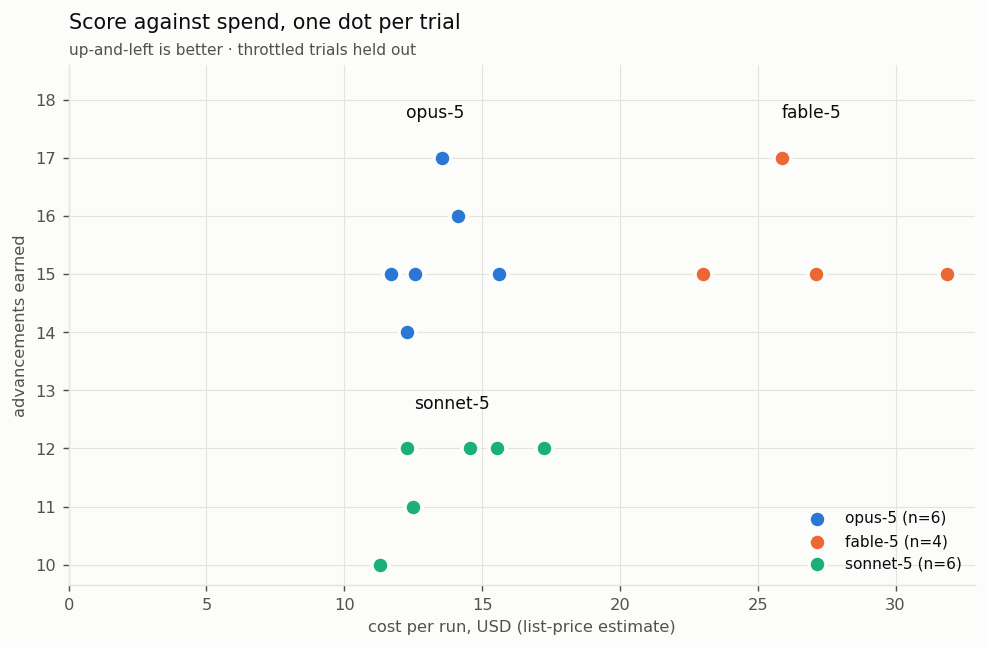

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.2))

for model in MODELS:
    d = VALID[VALID.model == model]
    ax.scatter(d.cost_usd, d.earned, s=90, color=color_of(model), zorder=3,
               edgecolor=SURFACE, linewidth=2, label=f"{short(model)} (n={len(d)})")
    # Direct label above the group's top dot (not its centroid, which lands on top of
    # the dots). The dot colour carries identity; the text stays in ink.
    ax.annotate(short(model), xy=(d.cost_usd.mean(), d.earned.max()),
                xytext=(0, 20), textcoords="offset points",
                ha="center", va="bottom", color=INK, fontsize=9.5)

ax.set_axisbelow(True)
ax.grid(True, axis="both")
ax.set_xlim(left=0)
ax.set_ylim(top=VALID.earned.max() + 1.6)  # headroom so the direct labels sit inside the axes
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("cost per run, USD (list-price estimate)")
ax.set_ylabel("advancements earned")
ax.set_title("Score against spend, one dot per trial", loc="left", fontsize=11.5, pad=20)
ax.text(0, 1.02, "up-and-left is better · throttled trials held out",
        transform=ax.transAxes, color=INK_SOFT, fontsize=8.5)
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
plt.show()